# AI Survey Workflows with EDSL
### Week 5 Lab — Graduate Workshop

---

## What is EDSL?

**EDSL** stands for **Expected Parrot Domain-Specific Language**. It is an open-source Python library that lets you conduct AI-powered surveys and experiments. Instead of paying thousands of dollars to recruit human survey respondents, EDSL lets you:

- Write survey questions exactly as they appear in published studies
- Create AI "agents" that simulate respondents with specific demographic profiles (e.g., a 55-year-old Republican from the South with a high school education)
- Tell the AI which language model to use (GPT-4, Claude, Gemini, etc.)
- Run the full survey and get back structured, analyzable data

**Why does this matter for social science?** Researchers are increasingly using AI to *replicate* or *pre-test* survey findings — checking whether AI agents reproduce the same demographic patterns as human respondents. This is exactly what your individual assignment asks you to do.

---

## How EDSL Works — The Big Picture

There are 5 core objects you need to learn. Think of them like this:

| Object | What it is | Analogy |
|--------|-----------|--------|
| `Question` | A single survey question | One row in a questionnaire |
| `Survey` | A collection of questions | The whole questionnaire |
| `Agent` | A simulated respondent with demographic traits | A survey participant |
| `Model` | The language model that generates answers | The "brain" of the agent |
| `Results` | The collected responses | Your dataset |

The basic workflow is always:
```
survey.by(agents).by(models).run() → results
```

---

## Sections in This Notebook

1. [Setup — Installation & API Keys](#1.-Setup)
2. [Question Types — Building Your Instrument](#2.-Question-Types)
3. [Surveys — Chaining Multiple Questions](#3.-Surveys)
4. [Agents — Creating Demographic Personas](#4.-Agents)
5. [Models — Choosing Your LLM](#5.-Models)
6. [Running Surveys — The `.by()` Pipeline](#6.-Running-Surveys)
7. [Extracting & Analyzing Results](#7.-Extracting-and-Analyzing-Results)
8. [Replication Game: GSS Example (End-to-End)](#8.-Replication-Game:-GSS-Example)
9. [Exercises](#9.-Exercises)
10. [References](#10.-References)


---
## 1. Setup

### 1.1 Install EDSL

EDSL is a standard Python package. You install it with `pip` just like any other library.

> **Note:** If you are running this on your own computer for the first time, uncomment the `!pip install edsl` line below and run it. On Google Colab, you must always run this cell. On a lab machine where EDSL is pre-installed, you can skip it.

In [2]:
# Uncomment the line below if EDSL is not yet installed in your environment:
# !pip install edsl

In [3]:
# Verify the installation worked by checking the version
import edsl
print(f"EDSL version: {edsl.__version__}")

EDSL version: 1.0.6


### 1.2 API Keys — What They Are and Why You Need Them

EDSL sends your survey questions to language model APIs (like OpenAI's GPT-4 or Anthropic's Claude). These APIs are not free — you need an **API key** to authenticate your requests, and you pay per token (roughly per word) used.

**How to get keys:**
- **OpenAI (GPT-4):** Sign up at [platform.openai.com](https://platform.openai.com/api-keys) — new accounts get free credits
- **Anthropic (Claude):** Sign up at [console.anthropic.com](https://console.anthropic.com) — free trial available
- **Google (Gemini):** Get a free key at [aistudio.google.com](https://aistudio.google.com/app/apikey)

**Security rules:**
- ⚠️ **Never paste your API key directly into a shared notebook** — anyone who sees the notebook can use your key and charge to your account
- ✅ Use environment variables (shown below) or a `.env` file
- ✅ On a personal laptop, add the key to your shell profile (`.bashrc`, `.zshrc`)

**Cost estimate:** A 9-agent single-question run with GPT-4o-mini costs approximately $0.01–0.05.

In [ ]:
import os

# ── Option A: Set key in this cell (for personal use only — do NOT share this notebook) ──
os.environ["OPENAI_API_KEY"] = "..."        # OpenAI / GPT
# os.environ["ANTHROPIC_API_KEY"] = "sk-ant-..." # Anthropic / Claude
# os.environ["GOOGLE_API_KEY"] = "AIza..."       # Google / Gemini

# ── Option B: Load from a .env file (recommended for security) ─────────────
# pip install python-dotenv, then:
# from dotenv import load_dotenv; load_dotenv()

# ── Check which keys are present ────────────────────────────────────────────
# This just checks whether the variable is set — it doesn't print the key itself
provider_map = {
    "OPENAI_API_KEY":     "OpenAI (GPT)",
    "ANTHROPIC_API_KEY":  "Anthropic (Claude)",
    "GOOGLE_API_KEY":     "Google (Gemini)",
}
found = [(name, provider_map[k]) for k, name in provider_map.items() if os.getenv(k)]
if found:
    for provider, _ in found:
        print(f"  ✓ {provider} key found")
else:
    print("  ⚠️  No API keys found. Set at least one key above before running surveys.")

  ✓ OpenAI (GPT) key found


### 1.3 Import Everything You Will Need

We import all the EDSL classes we will use in this notebook. Run this cell once at the start of every session — if you restart the kernel you will need to re-run it.

In [5]:
# ── EDSL core classes ────────────────────────────────────────────────────────
from edsl import (
    # Question types (we will use all of these)
    QuestionMultipleChoice,  # Pick one from a list
    QuestionFreeText,        # Open-ended text answer
    QuestionLinearScale,     # Numeric rating (e.g., 1–5 Likert scale)
    QuestionYesNo,           # Binary yes/no
    QuestionCheckBox,        # Select all that apply
    
    # Survey container
    Survey,                  # Holds an ordered list of questions
    
    # Agents (simulated respondents)
    Agent,                   # A single respondent with demographic traits
    AgentList,               # A collection of multiple agents
    
    # Language models
    Model,                   # A single LLM (e.g., GPT-4o)
    ModelList,               # Run the same survey on multiple models
    
    # Scenarios (optional — for parameterized questions)
    Scenario,                # A set of variable values for template questions
    ScenarioList,            # Multiple scenario conditions
)

# ── Analysis libraries ───────────────────────────────────────────────────────
import pandas as pd          # For data manipulation and summary statistics
import matplotlib.pyplot as plt  # For creating charts
import matplotlib.ticker as mtick  # For formatting axis ticks (e.g., percentages)

print("All imports successful")

All imports successful


---
## 2. Question Types

Every EDSL question requires two things at minimum:
- `question_name` — a Python-valid identifier (letters, numbers, underscores; no spaces). **This is how you reference the answer later.** Think of it as a variable name for the response.
- `question_text` — the actual survey question, exactly as you want the AI to see it.

Some question types have additional required parameters (like `question_options` for multiple choice).

> **For replication studies:** Use the *exact wording* from the original survey whenever possible. LLMs are sensitive to wording — even small paraphrases can shift response distributions.

### 2.1 Multiple Choice (`QuestionMultipleChoice`)

Use this for any question where respondents pick exactly one option from a fixed list — party identification, policy preferences, categorical attitudes.

In [7]:
# This replicates the GSS "PARTYID" question (simplified)
# Source: NORC General Social Survey, variable PARTYID
# See: https://gssdataexplorer.norc.org/variables/141/vshow

q_party = QuestionMultipleChoice(
    question_name="party_id",     # We will use this name to filter/select this answer later
    question_text=(
        "Generally speaking, do you usually think of yourself as a "
        "Republican, Democrat, Independent, or what?"
    ),
    question_options=[
        "Strong Democrat",
        "Not very strong Democrat",
        "Independent, close to Democrat",
        "Independent",
        "Independent, close to Republican",
        "Not very strong Republican",
        "Strong Republican",
        "Other party"
    ]
)

# .run() with no arguments sends the question to the default model with no agent persona.
# This is useful for quickly testing that your question is well-formed.
print("Running a quick test (no agent, default model)...")
result = q_party.run()

# .select() chooses which columns to display from the results object
# The column name is always the question_name we set above
result.select("party_id").print()

Running a quick test (no agent, default model)...


answer.party_id
Independent


**What just happened?** EDSL sent a prompt to the default language model saying, in effect: "Please answer this survey question and return exactly one of the listed options." The model answered as itself — no demographic persona assigned yet. We will add agents in Section 4.

### 2.2 Yes / No (`QuestionYesNo`)

Perfect for binary attitude items — the most common format in GSS and Pew replication targets. The model returns either `"Yes"` or `"No"` as a string (no free-form text).

In [8]:
# This replicates the GSS "GRASS" question — marijuana legalization
# Source: NORC General Social Survey, variable GRASS
# See: https://gssdataexplorer.norc.org/variables/285/vshow
# Human benchmark (GSS 2022): ~70% of adults said "Yes" (support legalization)
# Partisan breakdown: Democrats ~76%, Independents ~62%, Republicans ~44%

q_marijuana = QuestionYesNo(
    question_name="marijuana_legal",
    question_text="Do you think the use of marijuana should be made legal or not?"
)

# Quick test
result = q_marijuana.run()
result.select("marijuana_legal").print()

# The returned value is always the string "Yes" or "No"
# This makes it easy to compute percentages:
#   (df["answer.marijuana_legal"] == "Yes").mean() * 100

answer.marijuana_legal
Yes


### 2.3 Linear Scale (`QuestionLinearScale`) — Likert-Style Ratings

Use this whenever the original survey uses a numeric rating scale (1–5, 1–7, confidence ratings, etc.). You can provide labels for the anchor points (lowest and highest values) using the `option_labels` dictionary.

In [9]:
# This replicates the GSS confidence-in-institutions battery
# Source: NORC General Social Survey, variable CONLEGIS (confidence in Congress)
# See: https://gssdataexplorer.norc.org/variables/441/vshow
# The original GSS uses 3 categories; here we expand to a 5-point scale for richer data

q_confidence = QuestionLinearScale(
    question_name="confidence_congress",
    question_text=(
        "I am going to name some institutions in this country. "
        "As far as the people running these institutions are concerned, "
        "would you say you have a great deal of confidence, only some confidence, "
        "or hardly any confidence at all in them? — Congress"
    ),
    question_options=[1, 2, 3, 4, 5],  # The numeric scale values
    option_labels={
        1: "Hardly any confidence",  # Low anchor
        3: "Only some confidence",   # Midpoint label
        5: "A great deal of confidence"  # High anchor
    }
    # You do not need to label every point — just the anchors you want to communicate
)

result = q_confidence.run()
result.select("confidence_congress").print()  # Will return an integer (1–5)

answer.confidence_congress
1


### 2.4 Free Text (`QuestionFreeText`) — Open-Ended Answers

This asks the model to respond in its own words with no constraints. Good for open-ended GSS items like "most important problem" or for asking agents to explain their reasoning after a multiple-choice answer.

In [10]:
# This replicates the GSS "NATPROB" / "MOSTIMPT" type question
# Source: NORC General Social Survey — Most Important Problem
# Note: Free text responses are harder to quantify than closed-ended items;
# plan to use content analysis or topic modeling when comparing to human data.

q_problem = QuestionFreeText(
    question_name="most_important_problem",
    question_text=(
        "What do you think is the most important problem facing the country today? "
        "Please be specific and limit your answer to one sentence."
    )
    # The instruction at the end ("one sentence") helps control response length
)

result = q_problem.run()
result.select("most_important_problem").print()

answer.most_important_problem
"The most important problem facing the country today is addressing climate change and its wide-ranging impacts on the environment, economy, and public health."


### 2.5 Checkbox (`QuestionCheckBox`) — Select All That Apply

Use this for multi-select survey items. The model returns a list of the selected options. The `min_selections` and `max_selections` parameters let you constrain how many the model picks.

In [11]:
# This replicates a Pew Research media consumption question
# Source: Pew Research Center — News Platform Fact Sheet (2023)
# See: https://www.pewresearch.org/journalism/fact-sheet/news-platform-fact-sheet/
# Human benchmark: TV (~66%), online news (~86%), social media (~50%) among US adults

q_news = QuestionCheckBox(
    question_name="news_sources",
    question_text=(
        "Where do you regularly get news about politics and current events? "
        "Select all that apply."
    ),
    question_options=[
        "Television",
        "Online news websites or apps",
        "Social media (Facebook, X/Twitter, etc.)",
        "Print newspapers",
        "Radio",
        "Podcasts"
    ],
    min_selections=1,  # Must pick at least one
    max_selections=6   # Can pick all
)

result = q_news.run()
result.select("news_sources").print()  # Returns a list of selected options

answer.news_sources
"['Online news websites or apps', 'Social media (Facebook, X/Twitter, etc.)', 'Podcasts']"


---
## 3. Surveys — Chaining Multiple Questions

A `Survey` is an ordered sequence of questions. By default, all questions are asked independently — the model does not "remember" earlier answers when answering later ones. But EDSL gives you two powerful tools to change this:

1. **Answer piping** (`{{ question_name.answer }}`): Insert a prior answer directly into a later question's text — just like conditional question wording in real surveys.
2. **Skip rules** (`.add_skip_rule()`): Conditionally skip a question based on prior answers — like branching logic in Qualtrics.

### 3.1 Basic Multi-Question Survey with Answer Piping

In [12]:
# Question 1: Attitude on gun control
# Source: NORC General Social Survey, variable GUNLAW
# See: https://gssdataexplorer.norc.org/variables/591/vshow
q_guns = QuestionMultipleChoice(
    question_name="gun_control",
    question_text=(
        "In general, do you feel that the laws covering the sale of firearms "
        "should be made more strict, less strict, or kept as they are now?"
    ),
    question_options=["More strict", "Less strict", "Kept as they are"]
)

# Question 2: Follow-up reasoning (uses answer piping)
# The {{ gun_control.answer }} syntax inserts whatever q1 returned into q2's text.
# When the model sees q2, it will read: "You said gun laws should be 'More strict'. Why..."
q_guns_reason = QuestionFreeText(
    question_name="gun_control_reason",
    question_text=(
        "You said gun laws should be '{{ gun_control.answer }}'. "
        "Briefly, why do you feel that way? (One sentence only.)"
    )
)

# Assemble the survey — questions are asked IN ORDER
gun_survey = Survey(questions=[q_guns, q_guns_reason])

# Run it
result = gun_survey.run()

# Select both columns to see how q2 is conditioned on q1's answer
result.select("gun_control", "gun_control_reason").print()

answer.gun_control,answer.gun_control_reason
More strict,I believe stricter gun laws can help reduce gun violence and enhance public safety by ensuring that firearms are only in the hands of responsible and qualified individuals.


### 3.2 Survey with Skip Rules (Branching Logic)

Skip rules let you replicate survey branching — a common feature in real questionnaires ("If YES, go to Q5; if NO, skip to Q8"). The skip rule takes a Python expression that evaluates to True/False based on prior answers.

In [13]:
# A realistic example: only ask WHY someone is not registered if they said they are not registered

q_registered = QuestionYesNo(
    question_name="registered_voter",
    question_text="Are you currently registered to vote?"
)

q_not_registered_reason = QuestionFreeText(
    question_name="not_registered_reason",
    question_text="What is the main reason you are not registered to vote?"
)

# Build the survey and add the skip rule:
# "Skip q_not_registered_reason if registered_voter == 'Yes'"
# In other words: only ask the follow-up to people who said they are NOT registered.
branching_survey = (
    Survey([q_registered, q_not_registered_reason])
    .add_skip_rule(
        q_not_registered_reason,           # The question to potentially skip
        "registered_voter == 'Yes'"         # Skip if this is True
    )
)

result = branching_survey.run()
# If the model answered 'Yes', not_registered_reason will be None
result.select("registered_voter", "not_registered_reason").print()

/opt/anaconda3/lib/python3.12/site-packages/edsl/surveys/rules/rule.py:169: UserWarning: This uses the old syntax! Converting to Jinja2 style with { }.
Old expression: registered_voter == 'Yes'
New expression: {{ registered_voter.answer }} == 'Yes'
  warnings.warn(


answer.registered_voter,answer.not_registered_reason
Yes,None


---
## 4. Agents — Creating Demographic Personas

This is the **most important section for your replication assignment**.

An `Agent` is an AI entity whose responses are shaped by the `traits` dictionary you provide. When EDSL runs a survey, it prepends a system prompt to the model that describes these traits — essentially telling the LLM: *"You are a [Democrat/Republican/Independent] who is [age group], with [education level]..."*

**The goal:** Your agents' trait distributions should mirror the demographic cells in the paper you are replicating. If the GSS sample is 29% Democrat, 27% Republican, and 44% Independent, your agent pool should reflect those proportions.

> **Important naming convention:** Use the same trait names consistently because they will become column names in your results DataFrame. For example, `party` will appear as `agent.party` in the output.

### 4.1 Creating a Single Agent

In [14]:
# A detailed demographic persona matching a specific GSS respondent profile
# Traits can be any key-value pairs — choose names that match the paper's demographic breakdown

agent_young_democrat = Agent(
    traits={
        "party_affiliation": "Democrat",          # From GSS PARTYID variable
        "age_group": "18-34",                     # From GSS AGE (recoded into groups)
        "education": "college graduate",           # From GSS EDUC (recoded)
        "region": "Northeast",                     # From GSS REGION
        "gender": "female",                        # From GSS SEX
        "race_ethnicity": "White, non-Hispanic"   # From GSS RACECEN1
    }
)

# Preview: see the agent's traits
print("Agent traits:")
print(agent_young_democrat)

# Quick test: ask just one question to this single agent
result = q_marijuana.by(agent_young_democrat).run()
result.select("party_affiliation", "marijuana_legal").print()

Agent traits:
Agent(traits = {'party_affiliation': 'Democrat', 'age_group': '18-34', 'education': 'college graduate', 'region': 'Northeast', 'gender': 'female', 'race_ethnicity': 'White, non-Hispanic'})


agent.party_affiliation,answer.marijuana_legal
Democrat,Yes


### 4.2 Building an `AgentList` with a Demographic Grid

For replication, you need many agents — one (or more) for each demographic cell in your comparison. Python's list comprehension makes this concise. 

**Think of each cell** in the demographic grid as one agent. If you have 3 parties × 3 age groups × 4 education levels, that is 36 cells = 36 agents.

In [15]:
# Example: Create a party × age group grid of agents
# These 9 cells correspond to a common GSS demographic breakdown
# References:
#   Party distribution (GSS 2022): Democrats ~29%, Independents ~44%, Republicans ~27%
#   Age distribution varies by question — check the specific table in the codebook

parties    = ["Democrat", "Republican", "Independent"]
age_groups = ["18-34", "35-54", "55+"]

# This creates one agent per combination — 3 × 3 = 9 total
# In a real replication you would create more agents per cell to match sample sizes
agent_grid = AgentList(
    Agent(
        traits={
            "party": party,        # Will appear as "agent.party" in results
            "age_group": age       # Will appear as "agent.age_group" in results
        }
    )
    for party in parties
    for age in age_groups
)

print(f"Total agents created: {len(agent_grid)}")

# Preview the first few agents
for i, agent in enumerate(agent_grid[:4]):
    print(f"  Agent {i+1}: {agent.traits}")

Total agents created: 9
  Agent 1: {'party': 'Democrat', 'age_group': '18-34'}
  Agent 2: {'party': 'Democrat', 'age_group': '35-54'}
  Agent 3: {'party': 'Democrat', 'age_group': '55+'}
  Agent 4: {'party': 'Republican', 'age_group': '18-34'}


### 4.3 Weighted Agent Lists (Matching Real Sample Distributions)

In a real replication, you want your AI "sample" to have the same demographic mix as the human sample. If the paper reports that 35% of respondents were Democrats, roughly 35% of your agents should be Democrats.

One way to do this is to **replicate agents** proportionally:

In [16]:
# Approximate GSS 2022 party identification shares (3-category)
# Source: Smith et al. (2023). "General Social Survey, 2022." NORC at the University of Chicago.
# Available at: https://gss.norc.org/
# Note: these are rounded proportions; see the full codebook for exact cell sizes.

# Out of 30 total agents, allocate proportionally:
#   Democrats:    ~29% → 9 agents
#   Republicans:  ~27% → 8 agents
#   Independents: ~44% → 13 agents

weighted_agents = AgentList(
    [Agent(traits={"party": "Democrat",     "persona_id": f"dem_{i+1}"}) for i in range(9)] +
    [Agent(traits={"party": "Republican",   "persona_id": f"rep_{i+1}"}) for i in range(8)] +
    [Agent(traits={"party": "Independent",  "persona_id": f"ind_{i+1}"}) for i in range(13)]
)

print(f"Total agents: {len(weighted_agents)}")  # Should be 30

# Verify the distribution matches the intended proportions
from collections import Counter
party_counts = Counter(a.traits["party"] for a in weighted_agents)
print("\nParty distribution:")
for party, count in party_counts.items():
    print(f"  {party}: {count} agents ({count/len(weighted_agents)*100:.0f}%)")

Total agents: 30

Party distribution:
  Democrat: 9 agents (30%)
  Republican: 8 agents (27%)
  Independent: 13 agents (43%)


---
## 5. Models — Choosing Your Language Model

A `Model` object tells EDSL which language model API to use when generating responses. You can use a single model (most common) or run the same survey on multiple models simultaneously to see whether demographic patterns hold across different LLMs.

**Choosing a model for replication:**
- Use the **most capable** model your API access allows (GPT-4o, Claude 3.5 Sonnet, Gemini 1.5 Pro) for the most human-like responses
- **Temperature** controls randomness: 0.0 = always the same answer (good for reproducibility), higher = more varied responses
- For replication studies, a temperature of 0.0–0.3 is usually appropriate

In [17]:
# See all models available in your EDSL installation
# (Only models for which you have set an API key will actually work)
from edsl import Model

print("Available models:")
print(Model.available())

Available models:
ModelList([Model(model_name = 'claude-3-haiku-20240307', service_name = 'anthropic', temperature = 0.5, max_tokens = 1000, top_p = 1, frequency_penalty = 0, presence_penalty = 0, logprobs = False, top_logprobs = 3), Model(model_name = 'claude-haiku-4-5-20251001', service_name = 'anthropic', temperature = 0.5, max_tokens = 1000, top_p = 1, frequency_penalty = 0, presence_penalty = 0, logprobs = False, top_logprobs = 3), Model(model_name = 'claude-opus-4-1-20250805', service_name = 'anthropic', temperature = 0.5, max_tokens = 1000, top_p = 1, frequency_penalty = 0, presence_penalty = 0, logprobs = False, top_logprobs = 3), Model(model_name = 'claude-opus-4-20250514', service_name = 'anthropic', temperature = 0.5, max_tokens = 1000, top_p = 1, frequency_penalty = 0, presence_penalty = 0, logprobs = False, top_logprobs = 3), Model(model_name = 'claude-opus-4-5-20251101', service_name = 'anthropic', temperature = 0.5, max_tokens = 1000, top_p = 1, frequency_penalty = 0, pr

In [18]:
# ── Single model (most common for replication) ───────────────────────────────

# GPT-4o — state-of-the-art OpenAI model, good benchmark for alignment studies
gpt4o = Model("gpt-4o")

# Claude 3.5 Sonnet — Anthropic's best model for nuanced instruction-following
# claude = Model("claude-3-5-sonnet-20241022")

# GPT-4o-mini — faster and much cheaper, good for large-scale experiments
# gpt4o_mini = Model("gpt-4o-mini")

# ── Temperature control ───────────────────────────────────────────────────────
# temperature=0.0 makes the model deterministic (same question → same answer every time)
# This is recommended for replication studies to ensure reproducibility
gpt4o_deterministic = Model("gpt-4o", temperature=0.0)

# ── Run the same survey on multiple models (comparison) ──────────────────────
# Use ModelList to compare whether GPT and Claude give the same partisan patterns
model_comparison = ModelList([
    Model("gpt-4o"),
    # Model("claude-3-5-sonnet-20241022"),  # uncomment if you have an Anthropic key
])

print("Models configured ✓")
print(f"  - gpt4o: {gpt4o}")

Models configured ✓
  - gpt4o: Model('gpt-4o', temperature=0.5, max_tokens=1000, top_p=1, frequency_penalty=0, presence_penalty=0, logprobs=False, top_logprobs=3)


---
## 6. Running Surveys — The `.by()` Pipeline

The central syntax in EDSL is the **chained `.by()` call** followed by `.run()`:

```python
results = survey.by(agents).by(models).run()
```

Here is what this does step by step:
1. `survey` — your collection of questions
2. `.by(agents)` — ask every question to every agent (cross-product)
3. `.by(models)` — do this for every model (another cross-product)
4. `.run()` — send all the prompts to the APIs (runs in parallel), collect responses

**Result count formula:** `n_agents × n_models × n_scenarios` rows in your results.

> **Caching:** EDSL automatically caches every API response. If you run the same survey twice with the same configuration, the second run retrieves cached results — no API cost.

### 6.1 Minimal Run — Single Question, No Agent

In [19]:
# The simplest possible run: one question, default model, no persona
# Use this to check that a question is correctly formatted before scaling up

q_trust = QuestionMultipleChoice(
    question_name="trust_govt",
    question_text=(
        "How often can you trust the federal government in Washington to do what is right? "
        "Would you say just about always, most of the time, only some of the time, or never?"
    ),
    question_options=["Just about always", "Most of the time", "Only some of the time", "Never"]
    # Source: American National Election Studies (ANES) trust in government question
    # See: https://electionstudies.org/resources/anes-guide/top-tables/?id=098
)

# No .by() calls — uses default model and no agent
result = q_trust.run()
result.select("trust_govt").print()

answer.trust_govt
Only some of the time


### 6.2 Run with Agents and a Specific Model

In [20]:
# Three party-identified agents respond to the trust question
# We expect Democrats and Republicans to give different answers — does the AI reproduce this?

# Real-world benchmark for comparison:
# ANES 2020 shows trust in government differs significantly by party (partisans trust
# government more when their party is in power — known as "thermostatic" opinion)
# Source: Hetherington, M. & Rudolph, T. (2015). Why Washington Won't Work. University of Chicago Press.

party_agents = AgentList([
    Agent(traits={"party": "Democrat"}),
    Agent(traits={"party": "Republican"}),
    Agent(traits={"party": "Independent"}),
])

# Survey is just a single question here; .by() attaches agents and model
trust_survey = Survey(questions=[q_trust])

results = (
    trust_survey
    .by(party_agents)        # Ask each of the 3 agents
    .by(Model("gpt-4o"))    # Use GPT-4o as the LLM backend
    .run()                   # Execute all 3 API calls (in parallel)
)

# Show party next to the answer — are there partisan differences?
results.select("party", "trust_govt").print()

agent.party,answer.trust_govt
Democrat,Most of the time
Republican,Only some of the time
Independent,Only some of the time


### 6.3 Full Pipeline — Survey × Agent Grid × Multiple Models

In [21]:
# Two-question marijuana survey
# Question 1: The GSS GRASS yes/no item (our primary replication target)
# Question 2: A Likert-style follow-up on perceived harm

q_legal = QuestionYesNo(
    question_name="marijuana_legal",
    question_text="Do you think the use of marijuana should be made legal or not?"
    # Source: NORC GSS, variable GRASS — see https://gssdataexplorer.norc.org/variables/285/vshow
)

q_harm = QuestionLinearScale(
    question_name="marijuana_harm",
    question_text="How harmful to society do you think marijuana use is?",
    question_options=[1, 2, 3, 4, 5],
    option_labels={1: "Not at all harmful", 3: "Moderately harmful", 5: "Extremely harmful"}
    # This question is adapted from the Monitoring the Future survey (Johnston et al., 2023)
    # See: https://monitoringthefuture.org/
)

two_q_survey = Survey(questions=[q_legal, q_harm])

# 3 parties × 3 age groups = 9 demographic cells
demographic_agents = AgentList(
    Agent(traits={"party": party, "age_group": age})
    for party in ["Democrat", "Republican", "Independent"]
    for age in ["18-34", "35-54", "55+"]
)

# Run: 9 agents × 1 model = 9 result rows, each with answers to both questions
full_results = (
    two_q_survey
    .by(demographic_agents)
    .by(Model("gpt-4o"))   # Swap in a different model here to run a model comparison
    .run()
)

print(f"Total result rows: {len(full_results)}  (expected: 9 agents × 1 model = 9)")
full_results.select("party", "age_group", "marijuana_legal", "marijuana_harm").print()

Total result rows: 9  (expected: 9 agents × 1 model = 9)


agent.party,agent.age_group,answer.marijuana_legal,answer.marijuana_harm
Democrat,18-34,Yes,2
Democrat,35-54,Yes,2
Democrat,55+,Yes,2
Republican,18-34,Yes,3
Republican,35-54,No,3
Republican,55+,No,3
Independent,18-34,Yes,2
Independent,35-54,Yes,2
Independent,55+,Yes,3


---
## 7. Extracting and Analyzing Results

The `Results` object returned by `.run()` has built-in methods for quick inspection. But for real analysis, you will convert it to a **Pandas DataFrame** and use standard data science tools.

**Column naming in the DataFrame:**
- `agent.{trait_name}` — demographic traits (e.g., `agent.party`, `agent.age_group`)
- `answer.{question_name}` — question responses (e.g., `answer.marijuana_legal`)
- `model.model` — which LLM was used

### 7.1 Built-in Results Methods

In [22]:
# ── .select() — choose which columns to display ──────────────────────────────
# Column names omit the "agent." / "answer." prefix when using .select()
full_results.select("party", "age_group", "marijuana_legal").print()

print("\n" + "─"*60 + "\n")

# ── .filter() — keep only rows matching a condition ──────────────────────────
# The expression uses the trait/question names WITHOUT prefixes
full_results.filter("party == 'Democrat'").select("age_group", "marijuana_legal", "marijuana_harm").print()

print("\n" + "─"*60 + "\n")

# ── .sort_by() — reorder rows ─────────────────────────────────────────────────
full_results.sort_by("party", "age_group").select("party", "age_group", "marijuana_harm").print()


────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────



agent.party,agent.age_group,answer.marijuana_harm
Democrat,18-34,2
Democrat,35-54,2
Democrat,55+,2
Independent,18-34,2
Independent,35-54,2
Independent,55+,3
Republican,18-34,3
Republican,35-54,3
Republican,55+,3


### 7.2 Converting to Pandas and Computing Summary Statistics

In [23]:
# Convert to a standard Pandas DataFrame
df = full_results.to_pandas()

# Show all column names so you can see the naming convention
print("All columns in the DataFrame:")
print([c for c in df.columns if not c.startswith("prompt")])
print()

All columns in the DataFrame:
['agent.age_group', 'agent.agent_index', 'agent.agent_instruction', 'agent.agent_name', 'agent.party', 'answer.marijuana_harm', 'answer.marijuana_legal', 'cache_keys.marijuana_harm_cache_key', 'cache_keys.marijuana_legal_cache_key', 'cache_used.marijuana_harm_cache_used', 'cache_used.marijuana_legal_cache_used', 'comment.marijuana_harm_comment', 'comment.marijuana_legal_comment', 'generated_tokens.marijuana_harm_generated_tokens', 'generated_tokens.marijuana_legal_generated_tokens', 'iteration.iteration', 'model.frequency_penalty', 'model.inference_service', 'model.logprobs', 'model.max_tokens', 'model.model', 'model.model_index', 'model.presence_penalty', 'model.temperature', 'model.top_logprobs', 'model.top_p', 'question_options.marijuana_harm_question_options', 'question_options.marijuana_legal_question_options', 'question_text.marijuana_harm_question_text', 'question_text.marijuana_legal_question_text', 'question_type.marijuana_harm_question_type', 'qu

In [24]:
# Rename columns for easier analysis
# The full column names from results.to_pandas() always follow this pattern:
#   agent.{trait} and answer.{question_name}

df_clean = df.rename(columns={
    "agent.party":             "party",
    "agent.age_group":         "age_group",
    "answer.marijuana_legal":  "marijuana_legal",   # 'Yes' or 'No'
    "answer.marijuana_harm":   "marijuana_harm",    # 1–5 integer
    "model.model":             "model"
})

# ── Proportion saying 'Yes' by party ─────────────────────────────────────────
# This is the key comparison metric for a binary replication (matching GSS GRASS)
support_by_party = (
    df_clean
    .groupby("party")["marijuana_legal"]
    .apply(lambda x: (x == "Yes").mean() * 100)  # Convert to percentage
    .reset_index()
    .rename(columns={"marijuana_legal": "pct_support_ai"})
)
print("AI-simulated support for marijuana legalization (% Yes), by party:")
print(support_by_party.to_string(index=False))

print()

# ── Mean harm rating by party × age group ────────────────────────────────────
harm_table = (
    df_clean
    .groupby(["party", "age_group"])["marijuana_harm"]
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={"marijuana_harm": "mean_harm_rating"})
)
print("Mean perceived harm rating (1–5), by party and age group:")
print(harm_table.to_string(index=False))

AI-simulated support for marijuana legalization (% Yes), by party:
      party  pct_support_ai
   Democrat      100.000000
Independent      100.000000
 Republican       33.333333

Mean perceived harm rating (1–5), by party and age group:
      party age_group  mean_harm_rating
   Democrat     18-34               2.0
   Democrat     35-54               2.0
   Democrat       55+               2.0
Independent     18-34               2.0
Independent     35-54               2.0
Independent       55+               3.0
 Republican     18-34               3.0
 Republican     35-54               3.0
 Republican       55+               3.0


### 7.3 Visualization — Bar Charts for Comparing Groups

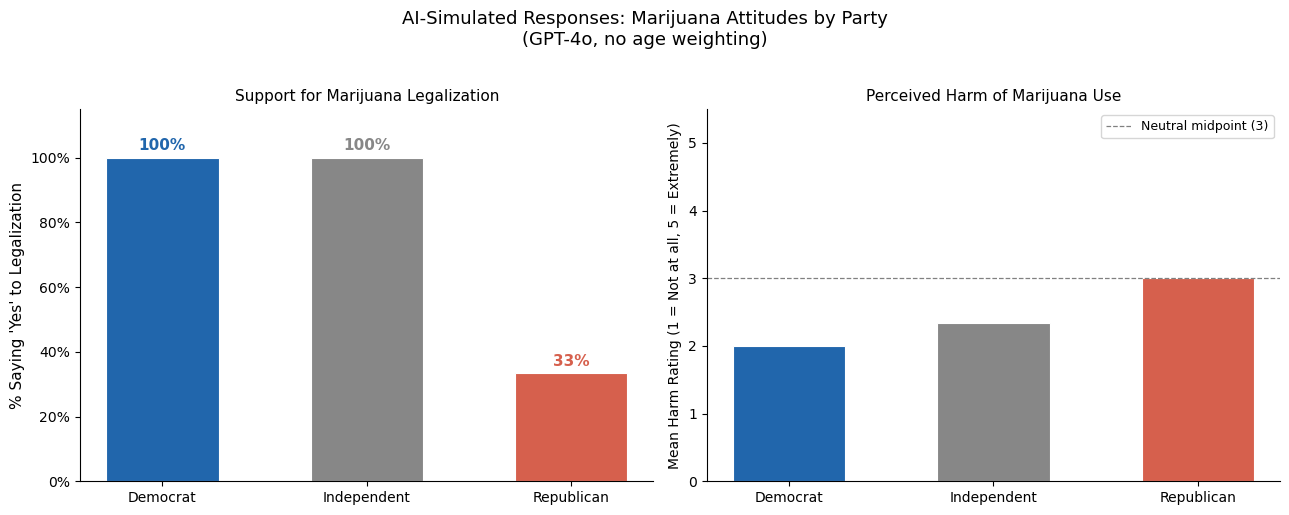

Figure saved as: ai_marijuana_by_party.png


In [25]:
# Color scheme matching political convention
party_colors = {
    "Democrat":    "#2166ac",  # Blue
    "Republican":  "#d6604d",  # Red
    "Independent": "#878787"   # Gray
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "AI-Simulated Responses: Marijuana Attitudes by Party\n"
    "(GPT-4o, no age weighting)",
    fontsize=13, y=1.02
)

# ── Left panel: % supporting legalization ────────────────────────────────────
ax0 = axes[0]
bars = ax0.bar(
    support_by_party["party"],
    support_by_party["pct_support_ai"],
    color=[party_colors[p] for p in support_by_party["party"]],
    edgecolor="white", linewidth=0.8, width=0.55
)
# Add percentage labels on each bar
for bar, val in zip(bars, support_by_party["pct_support_ai"]):
    ax0.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val:.0f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        color=party_colors[support_by_party.iloc[list(bars).index(bar)]["party"]]
    )
ax0.set_ylim(0, 115)
ax0.set_ylabel("% Saying 'Yes' to Legalization", fontsize=11)
ax0.set_title("Support for Marijuana Legalization", fontsize=11)
ax0.spines[["top", "right"]].set_visible(False)
ax0.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Right panel: mean harm rating ────────────────────────────────────────────
harm_by_party = df_clean.groupby("party")["marijuana_harm"].mean().reset_index()
ax1 = axes[1]
ax1.bar(
    harm_by_party["party"],
    harm_by_party["marijuana_harm"],
    color=[party_colors[p] for p in harm_by_party["party"]],
    edgecolor="white", linewidth=0.8, width=0.55
)
ax1.axhline(3, color="gray", linestyle="--", linewidth=0.9, label="Neutral midpoint (3)")
ax1.set_ylim(0, 5.5)
ax1.set_ylabel("Mean Harm Rating (1 = Not at all, 5 = Extremely)", fontsize=10)
ax1.set_title("Perceived Harm of Marijuana Use", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("ai_marijuana_by_party.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as: ai_marijuana_by_party.png")

---
## 8. Replication Game: GSS Example (End-to-End)

This section walks through a complete replication workflow — the same structure you will follow for your individual assignment.

### Research Target

**Question:** *"Do you think the use of marijuana should be made legal or not?"*  
**Source:** General Social Survey (GSS) 2022, variable `GRASS`  
**Data provider:** NORC at the University of Chicago  
**Where to access:** [GSS Data Explorer](https://gssdataexplorer.norc.org/variables/285/vshow)

**Published human findings (GSS 2022, approximate marginals):**

| Subgroup | % Supporting Legalization | Source |
|---|---|---|
| All adults | ~70% | Smith et al. (2023), GSS 2022 Codebook |
| Democrat | ~76% | GSS 2022, GRASS × PARTYID cross-tabulation |
| Independent | ~62% | GSS 2022, GRASS × PARTYID cross-tabulation |
| Republican | ~44% | GSS 2022, GRASS × PARTYID cross-tabulation |
| Age 18–34 | ~81% | GSS 2022, GRASS × AGE cross-tabulation |
| Age 35–54 | ~68% | GSS 2022, GRASS × AGE cross-tabulation |
| Age 55+ | ~52% | GSS 2022, GRASS × AGE cross-tabulation |

> **Why this question?** Marijuana legalization shows large, well-documented partisan and generational gaps in human data, making it a good test of whether AI agents reproduce the same demographic structure.

### Step 1: Define the Survey Question (Exact Wording)

In [26]:
# IMPORTANT: Use the exact GSS question wording.
# Even small paraphrases can shift response distributions.
# The original GSS GRASS wording is:
#   "Do you think the use of marijuana should be made legal or not?"
# Source: NORC GSS 2022 Questionnaire — https://gss.norc.org/documents/codebook/GSS_Codebook.pdf

gss_marijuana = QuestionYesNo(
    question_name="marijuana_legal",
    question_text="Do you think the use of marijuana should be made legal or not?"
)

gss_survey = Survey(questions=[gss_marijuana])

print("Survey defined ✓")
print(f"  Question: {gss_marijuana.question_text}")

Survey defined ✓
  Question: Do you think the use of marijuana should be made legal or not?


### Step 2: Build Agents Matching the GSS Demographic Breakdown

For a party × age cross-tabulation (the most common format in GSS reports), we create one agent per cell. For a more robust analysis, you would create multiple agents per cell and weight them by actual GSS cell sizes from the codebook.

In [27]:
# 3 parties × 3 age groups = 9 demographic cells
# These match the breakdowns reported in GSS 2022 toplines
# For a stronger replication: look up the exact N per cell in the GSS codebook
# and create that many agents per cell

gss_parties    = ["Democrat", "Republican", "Independent"]
gss_age_groups = ["18-34", "35-54", "55+"]

gss_agents = AgentList(
    Agent(
        traits={
            "party_affiliation": party,
            "age_group": age,
            # Including a brief background helps the model understand context
            # This mirrors what the human respondent knows about themselves
            "background": (
                f"You are an American adult in the {age} age group "
                f"who identifies as {party}."
            )
        }
    )
    for party in gss_parties
    for age in gss_age_groups
)

print(f"Total GSS-matched agents: {len(gss_agents)}")
print("\nSample agents:")
for a in gss_agents[:3]:
    print(f"  party={a.traits['party_affiliation']}, age={a.traits['age_group']}")

Total GSS-matched agents: 9

Sample agents:
  party=Democrat, age=18-34
  party=Democrat, age=35-54
  party=Democrat, age=55+


### Step 3: Run the Survey

In [28]:
# Using GPT-4o for this replication
# For your assignment: document which model you used and why
# Note: Different models may show different alignment with human data

replication_model = Model("gpt-4o")

print("Running GSS replication survey...")
print(f"  Config: {len(gss_agents)} agents × 1 model = {len(gss_agents)} API calls")

gss_results = (
    gss_survey
    .by(gss_agents)
    .by(replication_model)
    .run()
)

print(f"\nCompleted. Result rows: {len(gss_results)}")
gss_results.select("party_affiliation", "age_group", "marijuana_legal").print()

Running GSS replication survey...
  Config: 9 agents × 1 model = 9 API calls

Completed. Result rows: 9


agent.party_affiliation,agent.age_group,answer.marijuana_legal
Democrat,18-34,Yes
Democrat,35-54,Yes
Democrat,55+,Yes
Republican,18-34,Yes
Republican,35-54,No
Republican,55+,No
Independent,18-34,Yes
Independent,35-54,Yes
Independent,55+,Yes


### Step 4: Compute AI Response Rates and Compare to Human Data

In [29]:
# Convert to DataFrame
gss_df = gss_results.to_pandas()

# Rename for clarity
gss_df = gss_df.rename(columns={
    "agent.party_affiliation": "party",
    "agent.age_group":         "age_group",
    "answer.marijuana_legal":  "ai_response"
})

# ── AI support rates by party ─────────────────────────────────────────────────
ai_by_party = (
    gss_df.groupby("party")["ai_response"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index()
    .rename(columns={"ai_response": "ai_pct_support"})
)

# ── Human benchmark (GSS 2022) ────────────────────────────────────────────────
# Source: Smith, Tom W., Michael Davern, Jeremy Freese, and Stephen L. Morgan.
#   General Social Surveys, 1972-2022 [machine-readable data file].
#   Chicago: NORC at the University of Chicago, 2023.
#   Data accessed via GSS Data Explorer: https://gssdataexplorer.norc.org/
human_by_party = pd.DataFrame({
    "party":            ["Democrat", "Independent", "Republican"],
    "human_pct_support": [76.0,        62.0,           44.0]
})

# Merge AI and human data
comparison_party = ai_by_party.merge(human_by_party, on="party")
comparison_party["difference"] = comparison_party["ai_pct_support"] - comparison_party["human_pct_support"]

print("Party-level comparison (AI vs. Human):")
print(comparison_party.to_string(index=False))
print()

# Mean Absolute Error — a scalar measure of overall alignment
mae = comparison_party["difference"].abs().mean()
print(f"Mean Absolute Error (MAE): {mae:.1f} percentage points")
print("(Lower MAE = closer alignment with human data)")

Party-level comparison (AI vs. Human):
      party  ai_pct_support  human_pct_support  difference
   Democrat      100.000000               76.0   24.000000
Independent      100.000000               62.0   38.000000
 Republican       33.333333               44.0  -10.666667

Mean Absolute Error (MAE): 24.2 percentage points
(Lower MAE = closer alignment with human data)


### Step 5: Comparison Visualization — The Core Figure for Your Report

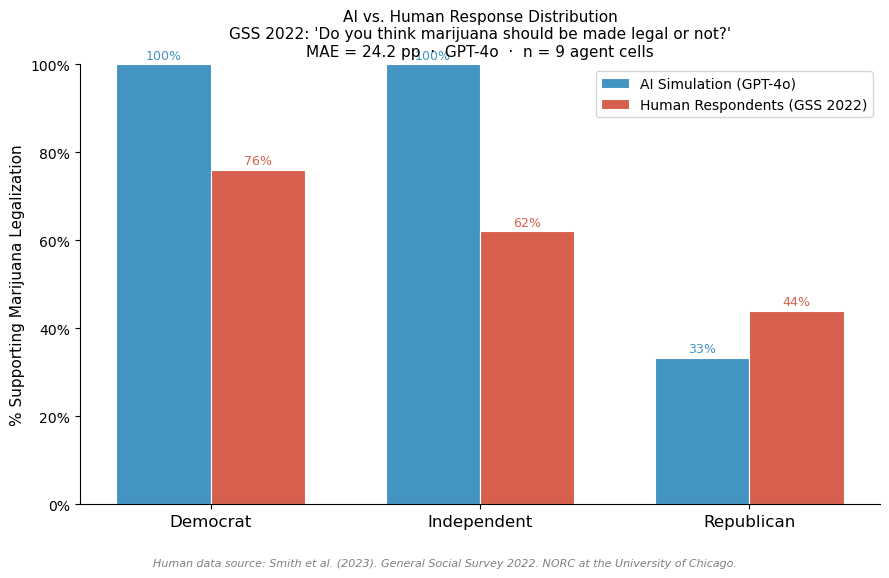

Figure saved as: gss_replication_comparison.png


In [30]:
# This is the key figure for your replication report:
# A side-by-side bar chart comparing AI and human response rates

x_pos = range(len(comparison_party))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))

# AI bars
bars_ai = ax.bar(
    [i - bar_width/2 for i in x_pos],
    comparison_party["ai_pct_support"],
    bar_width,
    label=f"AI Simulation (GPT-4o)",
    color="#4393c3",  # Blue for AI
    edgecolor="white", linewidth=0.8
)

# Human bars
bars_human = ax.bar(
    [i + bar_width/2 for i in x_pos],
    comparison_party["human_pct_support"],
    bar_width,
    label="Human Respondents (GSS 2022)",
    color="#d6604d",  # Red/orange for human
    edgecolor="white", linewidth=0.8
)

# Add value labels on bars
for bar in bars_ai:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f"{bar.get_height():.0f}%", ha="center", fontsize=9, color="#4393c3")
for bar in bars_human:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.2,
            f"{bar.get_height():.0f}%", ha="center", fontsize=9, color="#d6604d")

ax.set_xticks(list(x_pos))
ax.set_xticklabels(comparison_party["party"], fontsize=12)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("% Supporting Marijuana Legalization", fontsize=11)
ax.set_title(
    "AI vs. Human Response Distribution\n"
    "GSS 2022: 'Do you think marijuana should be made legal or not?'\n"
    f"MAE = {mae:.1f} pp  ·  GPT-4o  ·  n = {len(gss_agents)} agent cells",
    fontsize=11
)
ax.legend(fontsize=10, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)

# Caption with data source — include this in your report
fig.text(
    0.5, -0.04,
    "Human data source: Smith et al. (2023). General Social Survey 2022. NORC at the University of Chicago.",
    ha="center", fontsize=8, color="gray", style="italic"
)

plt.tight_layout()
plt.savefig("gss_replication_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as: gss_replication_comparison.png")

### Step 6: Interpretation Template

Fill in this table for your report. Honest, specific interpretation is what separates a strong replication report from a weak one.

In [31]:
# Helper: auto-generate a first-pass interpretation table
# You should edit and expand on this in your written report

print("=" * 65)
print("REPLICATION INTERPRETATION — fill in the right column")
print("=" * 65)
questions = [
    "Does the AI replicate the partisan DIRECTION of the effect?",
    "Which party shows the largest AI–human gap?",
    "Does the AI over- or under-estimate support overall?",
    "Is the partisan GAP size similar to the human data?",
    "Does the pattern differ by age group?",
    "Plausible explanation for the largest divergence?",
    "Limitation of this AI replication approach?"
]
for i, q in enumerate(questions, 1):
    print(f"\n{i}. {q}")
    print("   → [YOUR ANSWER HERE]")

REPLICATION INTERPRETATION — fill in the right column

1. Does the AI replicate the partisan DIRECTION of the effect?
   → [YOUR ANSWER HERE]

2. Which party shows the largest AI–human gap?
   → [YOUR ANSWER HERE]

3. Does the AI over- or under-estimate support overall?
   → [YOUR ANSWER HERE]

4. Is the partisan GAP size similar to the human data?
   → [YOUR ANSWER HERE]

5. Does the pattern differ by age group?
   → [YOUR ANSWER HERE]

6. Plausible explanation for the largest divergence?
   → [YOUR ANSWER HERE]

7. Limitation of this AI replication approach?
   → [YOUR ANSWER HERE]


### Note: Running above code cost me 0.01 USD (9 requests and 757 input tokens). Your costs may vary based on the model you choose and the number of agents you create.

---
## 9. Exercises

Work through these during the lab session. Exercises 1–3 are designed for 25 minutes in pairs. The challenge extension is optional.

### Exercise 1 — Swap the Model (10 minutes)

**Task:** Re-run the GSS replication in Section 8 using a different language model (e.g., `claude-3-5-sonnet-20241022` or `gpt-4o-mini`). Does the direction of the partisan gap change? Does the MAE improve or worsen?

**What to look for:** Some models may be more "politically balanced" and show weaker partisan differentiation than human data. Others may exaggerate it.

In [ ]:
# Exercise 1: Replace 'gpt-4o' with a different model and re-run

# Step 1: Choose your model
alternative_model = Model("gpt-4o")  # ← change this string

# Step 2: Run the survey
# ex1_results = gss_survey.by(gss_agents).by(alternative_model).run()

# Step 3: Compute AI support rates and MAE
# ex1_df = ex1_results.to_pandas()
# ...

# Step 4: Compare your MAE to the one from Section 8
# ...

### Exercise 2 — Add an Age Group Breakdown (15 minutes)

**Task:** Extend the replication to analyze AI support rates by `age_group` (18–34, 35–54, 55+). Create a grouped bar chart comparing AI vs. GSS 2022 human data by age.

**Human benchmark (GSS 2022):** 18–34 → 81%, 35–54 → 68%, 55+ → 52%

**Hint:** Group by `age_group` in your Pandas DataFrame. The column will be `agent.age_group`.

In [ ]:
# Exercise 2: Age group breakdown

# Step 1: Compute AI support rates by age group
# ai_by_age = (
#     gss_df.groupby("age_group")["ai_response"]
#     .apply(lambda x: (x == "Yes").mean() * 100)
#     .reset_index()
# )

# Step 2: Human benchmarks from GSS 2022
# human_by_age = pd.DataFrame({
#     "age_group":          ["18-34", "35-54", "55+"],
#     "human_pct_support":  [81.0,    68.0,    52.0]
# })

# Step 3: Merge and plot a grouped bar chart
# ...

### Exercise 3 — New GSS Question (20 minutes)

**Task:** Choose a different GSS variable, find its published cross-tabulation by party or demographics, and build a complete replication pipeline from scratch.

**Suggested GSS variables:**
- `CAPPUN` — Support for capital punishment
- `GUNLAW` — Gun law preference (more strict / less strict / same)
- `CONPRESS` — Confidence in the press
- `ABANY` — Abortion for any reason (Yes/No)

**Data access:** [GSS Data Explorer](https://gssdataexplorer.norc.org/) — search by variable name, then click "Trends" for year-over-year data and "Cross-tabulate" for demographic breakdowns.

**Your pipeline:**
1. Find the published breakdown → record numbers in a `human_data` DataFrame
2. Write the EDSL question using exact GSS wording
3. Build agents matching the demographic cells
4. Run and compare

In [ ]:
# Exercise 3: Build your own replication

# Step 1: Define your question (exact wording from GSS)
# q_your_question = QuestionYesNo(
#     question_name="...",
#     question_text="..."
# )

# Step 2: Build agents matching your chosen cross-tabulation
# your_agents = AgentList(...)

# Step 3: Run
# your_results = Survey([q_your_question]).by(your_agents).by(Model('gpt-4o')).run()

# Step 4: Compute and compare
# ...

### Challenge Extension — Persona Sensitivity Analysis

**Research question:** Does giving the agent a rich narrative biography (vs. bare demographic traits) change the response distribution? This relates to a live debate in the LLM alignment literature.

**Task:** Use `ScenarioList` to test two agent description conditions on the same question:
- **Condition A:** Bare traits only (just `party` and `age_group`)
- **Condition B:** Full narrative bio ("You are a 28-year-old Democratic woman who grew up in Chicago...")

Compare the response distributions. Does richer context produce larger or smaller divergence from human GSS data?

**Reference:** Argyle et al. (2023) studied this question systematically — see the References section.

In [ ]:
# Challenge: Test two agent description styles

# Condition A: Bare traits
# agents_bare = AgentList([
#     Agent(traits={"party": "Democrat", "age_group": "18-34"}),
#     Agent(traits={"party": "Republican", "age_group": "18-34"}),
# ])

# Condition B: Full narrative bio
# agents_rich = AgentList([
#     Agent(traits={
#         "party": "Democrat",
#         "age_group": "18-34",
#         "bio": (
#             "You are a 26-year-old registered Democrat who voted in the last election. "
#             "You grew up in a liberal household, attended a large state university, and "
#             "work in tech. You follow politics closely and have strong opinions."
#         )
#     }),
#     Agent(traits={
#         "party": "Republican",
#         "age_group": "18-34",
#         "bio": (
#             "You are a 29-year-old registered Republican who voted in the last election. "
#             "You come from a rural conservative area, attend church weekly, and "
#             "work in a trade. You are skeptical of government programs."
#         )
#     }),
# ])

# Run both conditions and compare MAE against human data
# ...

---
## 10. References

### Data Sources

**General Social Survey (GSS)**  
Smith, Tom W., Michael Davern, Jeremy Freese, and Stephen L. Morgan. *General Social Surveys, 1972-2022* [machine-readable data file]. Principal Investigator, Tom W. Smith; Co-Principal Investigators, Michael Davern, Jeremy Freese, and Stephen Morgan. Chicago: NORC at the University of Chicago, 2023.  
Access: https://gss.norc.org/ | Data explorer: https://gssdataexplorer.norc.org/

**Pew Research Center**  
Pew Research Center. (2023). *News Platform Fact Sheet.* Journalism & Media.  
Access: https://www.pewresearch.org/journalism/fact-sheet/news-platform-fact-sheet/

**American National Election Studies (ANES)**  
American National Election Studies. (2021). *ANES 2020 Time Series Study Full Release* [dataset and documentation].  
Access: https://electionstudies.org/data-center/2020-time-series-study/

**Monitoring the Future**  
Johnston, L.D., Miech, R.A., O'Malley, P.M., Bachman, J.G., Schulenberg, J.E., & Patrick, M.E. (2023). *Monitoring the Future national survey results on drug use: 1975-2022.* Ann Arbor: Institute for Social Research, University of Michigan.  
Access: https://monitoringthefuture.org/

---

### EDSL Software

**Expected Parrot (2024).** *EDSL: Expected Parrot Domain-Specific Language* [software].  
GitHub: https://github.com/expectedparrot/edsl  
Documentation: https://docs.expectedparrot.com/  
Install: `pip install edsl`

---

### Key Academic References on AI Survey Simulation

**Argyle, L.P., Busby, E., Fulda, N., Gubler, J., Rytting, C., & Wingate, D. (2023).** Out of One, Many: Using Language Models to Simulate Human Samples. *Political Analysis, 31*(3), 337–351.  
This paper coined the term "silicon sampling" and provided the first systematic evaluation of whether LLMs can replicate human survey demographics. *(Foundational reference for your assignment.)*

**Santurkar, S., Durmus, E., Ladd, F., Lee, E., Liang, P., & Hashimoto, T. (2023).** Whose Opinions Do Language Models Reflect? *Proceedings of the 40th International Conference on Machine Learning (ICML 2023).*  
Evaluated alignment between LLM responses and US public opinion across demographics. Found consistent demographic skews.

**Bisbee, J., Clinton, J., Dorff, C., Kenkel, B., & Larson, J. (2023).** Synthetic Replacements for Human Survey Data? The Perils of Large Language Models. *Political Analysis.*  
A cautionary paper: finds that LLMs often fail to reproduce the *magnitude* of opinion gaps even when they reproduce the *direction*.

**Hetherington, M.J. & Rudolph, T.J. (2015).** *Why Washington Won't Work: Polarization, Political Trust, and the Governing Crisis.* University of Chicago Press.  
Background reading on partisan differences in government trust (the context for the ANES trust question used in Section 6).

---

### A Note on Citing AI-Generated Data

When you include AI-simulated results in your report, always:
1. State which model you used (e.g., GPT-4o, accessed March 2025)
2. State the EDSL version (`import edsl; edsl.__version__`)
3. Report your temperature setting and any other model parameters
4. Note that AI responses may vary across runs unless temperature=0.0
5. Never present AI-generated figures as human survey data
